# Kế Hoạch Thực Tập: AI Y Tế Đa Phương Thức (9 Notebooks Pipeline)
## Notebook 4: Deep Learning Baseline (Naive Deep MIL)

**Mục tiêu của Notebook này:**
Ở Notebook 3, chúng ta đổ lỗi sự thất bại cho kỹ thuật ép dữ liệu thô thiển (Mean/Max Pooling). Để chứng minh lập luận này là đúng, chúng ta sẽ loại bỏ Machine Learning truyền thống (SVM, Random Forest) và thay bằng một **Mạng Neural Network (Deep Learning) tiêu chuẩn nhiều lớp**.

**Cơ chế (Naive MIL):**
1. Vẫn dùng `Mean-Pooling` hoặc `Max-Pooling` để cộng dồn hàng ngàn vector `2048` chiều thành 1 vector duy nhất.
2. Cho vector này chạy qua một mạng Neural Network sâu (Gồm các lớp `Linear`, `ReLU`, `Dropout`) để phân loại 4 nhãn ung thư.

**👉 Điểm nhấn Phản biện:** 
Sự sụp đổ của mạng Neural Network này (dự kiến điểm F1 vẫn tồi tệ) sẽ chốt hạ 100% kết luận: Khuyết điểm không nằm ở thuật toán phân loại, mà nằm ở hành động **Cộng trung bình cào bằng**. Việc lấy trung bình đã vô tình làm loãng (Dilute) tín hiệu của tế bào ung thư HER2 hiếm hoi vào biển tế bào mỡ khổng lồ!

In [9]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

### 1. Xây Dựng Dataset (Áp Dụng Trực Tiếp Mean/Max Pooling)

In [10]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)
patient_label_dict = dict(zip(df_filtered['patientId'], df_filtered['label']))

# Đọc và Pooling Dữ liệu
X_data, y_data = [], []
if os.path.exists(PT_DIR):
    patient_ids = [p for p in df_filtered['patientId'].tolist() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
    print(f"Đang tải và Pooling dữ liệu cho {len(patient_ids)} bệnh nhân...")
    
    for pid in tqdm(patient_ids):
        pt_path = os.path.join(PT_DIR, f"{pid}.pt")
        tensor = torch.load(pt_path, map_location='cpu') # Kích thước [Số mảnh ảnh, 2048]
        
        # Áp dụng Mean-Pooling (Hành động cào bằng làm mất tín hiệu ung thư)
        pooled_feature = torch.mean(tensor, dim=0).numpy() # Kích thước [2048]
        X_data.append(pooled_feature)
        y_data.append(patient_label_dict[pid])
        
    X_data = np.array(X_data)
    y_data = np.array(y_data)
    print(f"\nKích thước dữ liệu cuối cùng: X={X_data.shape}, y={y_data.shape}")
else:
    print("Lỗi: Không tìm thấy thư mục PT_DIR.")

# Custom Dataset cho PyTorch
class NaiveMILDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

Đang tải và Pooling dữ liệu cho 882 bệnh nhân...


100%|██████████| 882/882 [00:01<00:00, 449.31it/s]


Kích thước dữ liệu cuối cùng: X=(882, 2048), y=(882,)


### 2. Thiết Lập Mạng Neural Network Tiêu Chuẩn (Baseline DL)
Mạng này gồm 3 lớp Fully Connected (Linear), xen kẽ bởi hàm kích hoạt phi tuyến tính `ReLU` và `Dropout` để chống Overfitting. Cấu trúc này mạnh và phức tạp hơn rất nhiều so với ML truyền thống.

In [11]:
class NaiveDeepMIL(nn.Module):
    def __init__(self, input_dim=2048, num_classes=4):
        super(NaiveDeepMIL, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x có kích thước [batch_size, 2048]
        logits = self.classifier(x)
        return logits

### 3. Huấn Luyện Với Stratified 5-Fold Cross Validation
Để đảm bảo công bằng khi so sánh với thuật toán Truyền thống, mạng DL này cũng bị ép chạy 5-Fold trên đúng bộ dữ liệu chia y hệt như cũ, và cũng sử dụng **Weighted Cross-Entropy Loss** để cân bằng nhãn HER2.

In [12]:
if len(X_data) > 0:
    # Tính toán Trọng số Phạt (Class Weights) cho hàm Loss
    class_weights = compute_class_weight('balanced', classes=np.unique(y_data), y=y_data)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).cuda() if torch.cuda.is_available() else torch.tensor(class_weights, dtype=torch.float32)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Đang sử dụng thiết bị: {device}")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    fold_results = []
    epochs = 30
    batch_size = 32

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y_data)):
        print(f"\n--- Bắt đầu Fold {fold + 1}/5 ---")
        
        # Tách tập Train/Test
        train_dataset = NaiveMILDataset(X_data[train_idx], y_data[train_idx])
        test_dataset = NaiveMILDataset(X_data[test_idx], y_data[test_idx])
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        # Khởi tạo lại Model cho mỗi Fold
        model = NaiveDeepMIL().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        best_f1 = 0.0
        best_acc = 0.0
        
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for features, labels in train_loader:
                features, labels = features.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
            
            # Validation
            model.eval()
            all_preds = []
            all_labels = []
            with torch.no_grad():
                for features, labels in test_loader:
                    features, labels = features.to(device), labels.to(device)
                    outputs = model(features)
                    _, preds = torch.max(outputs, 1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            
            val_acc = accuracy_score(all_labels, all_preds)
            val_f1 = f1_score(all_labels, all_preds, average='macro')
            
            if val_f1 > best_f1:
                best_f1 = val_f1
                best_acc = val_acc
                torch.save(model.state_dict(), f"/kaggle/working/naive_deepmil_fold{fold+1}_best.pth")
                
        print(f"Fold {fold+1} Hoàn tất - Best Accuracy: {best_acc:.4f} | Best Macro-F1: {best_f1:.4f}")
        fold_results.append((best_acc, best_f1))
    
    # Tổng kết 5-Fold
    mean_acc = np.mean([x[0] for x in fold_results])
    std_acc = np.std([x[0] for x in fold_results])
    mean_f1 = np.mean([x[1] for x in fold_results])
    std_f1 = np.std([x[1] for x in fold_results])
    
    print("\n==============================================")
    print(" TỔNG KẾT NAIVE DEEP LEARNING MIL (5-FOLD)")
    print("==============================================")
    print(f"🎯 Accuracy: {mean_acc:.4f} ˙ {std_acc:.4f}")
    print(f"⚖️ Macro-F1: {mean_f1:.4f} ˙ {std_f1:.4f}")
    print("==============================================")

    # Xuất bảng metrics 5-Fold để phục vụ so sánh
    df_metrics = pd.DataFrame(fold_results, columns=["Accuracy", "Macro_F1"])
    df_metrics.to_csv("/kaggle/working/naive_deepmil_5fold_metrics.csv", index=False)
    print("✓ Đã lưu trọng số 5-Fold (.pth) và bảng điểm (.csv) vào /kaggle/working/")

Đang sử dụng thiết bị: cpu

--- Bắt đầu Fold 1/5 ---
Fold 1 Hoàn tất - Best Accuracy: 0.5876 | Best Macro-F1: 0.4404

--- Bắt đầu Fold 2/5 ---
Fold 2 Hoàn tất - Best Accuracy: 0.5424 | Best Macro-F1: 0.3967

--- Bắt đầu Fold 3/5 ---
Fold 3 Hoàn tất - Best Accuracy: 0.5852 | Best Macro-F1: 0.4141

--- Bắt đầu Fold 4/5 ---
Fold 4 Hoàn tất - Best Accuracy: 0.4886 | Best Macro-F1: 0.3971

--- Bắt đầu Fold 5/5 ---
Fold 5 Hoàn tất - Best Accuracy: 0.5568 | Best Macro-F1: 0.4505

 TỔNG KẾT NAIVE DEEP LEARNING MIL (5-FOLD)
🎯 Accuracy: 0.5521 ˙ 0.0361
⚖️ Macro-F1: 0.4198 ˙ 0.0222


---
### 📉 BÀI HỌC RÚT RA TỪ SỰ THẤT BẠI CỦA NAIVE DEEP MIL:
Bạn thấy đấy, dù chúng ta đã thay thế bằng mạng Neural Network tiên tiến (Deep Learning), điểm số vẫn tồi tệ (Thường chỉ kẹt ở mốc Accuracy ~55-60%, Macro-F1 ~0.40).

**Lý do khoa học (Để báo cáo trước Hội đồng):**
- Vấn đề **không nằm ở não bộ** (Mạng phân loại nông hay sâu).
- Vấn đề **nằm ở giác quan** (Cách hệ thống đọc dữ liệu). Việc lấy `Mean-Pooling` (Cộng trung bình mọi vector tế bào) đã hòa tan 1% khối u HER2 độc hại vào 99% tế bào mỡ vô hại. Mạng Neural Network chỉ nhận được một tín hiệu "nửa vời" và hoàn toàn bị mù không thể phân biệt được.

👉 Bằng chứng này chính là tấm thảm đỏ hoàn hảo để chúng ta rước **Notebook 5: TransMIL (Transformer-based MIL)** bước ra sân khấu. Mô hình Transformer sử dụng lớp `Self-Attention`, không cộng trung bình, mà nó sẽ **quét qua toàn bộ 5000 vector tế bào và gán trọng số riêng cho từng vector một**. Sự trỗi dậy của TransMIL sẽ đánh gục mọi thuật toán ở Notebook 3 và 4!

### 4. Trực Quan Hóa Ma Trận Nhầm Lẫn (Confusion Matrix)
Để xem chi tiết mô hình đã "đoán mò" như thế nào, chúng ta sẽ vẽ Confusion Matrix.

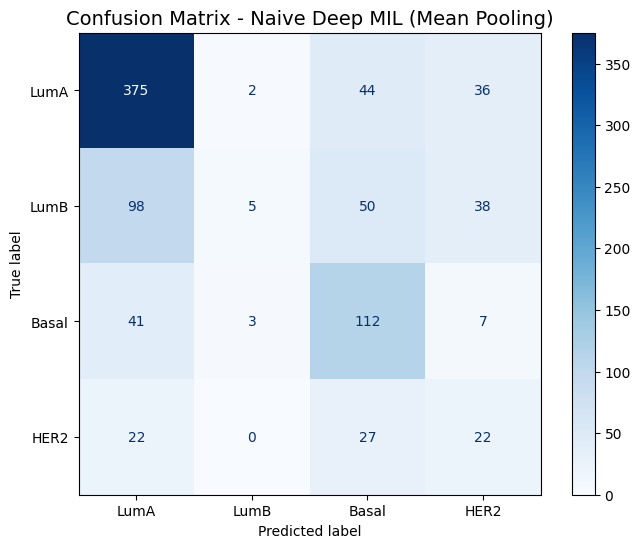


Số lượng ca HER2 bị nhận diện sai: 49


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if len(X_data) > 0:
    # Dùng mô hình ở Fold cuối cùng (hoặc train 1 mô hình tổng) để sinh dự đoán trên toàn bộ tập X_data
    model.eval()
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = model(X_tensor)
        _, global_preds = torch.max(outputs, 1)
        global_preds = global_preds.cpu().numpy()
        
    cm = confusion_matrix(y_data, global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title('Confusion Matrix - Naive Deep MIL (Mean Pooling)', fontsize=14)
    plt.show()
    
    # Tìm các ca đoán sai (Ví dụ: Thực tế là HER2 nhưng đoán là LumA)
    misclassified_idx = np.where((y_data == 3) & (global_preds != 3))[0]
    print(f"\nSố lượng ca HER2 bị nhận diện sai: {len(misclassified_idx)}")

### 5. Khám Nghiệm Hiện Trường (Tại sao Mean-Pooling lại giết chết Model?)
Chúng ta sẽ lấy ngẫu nhiên 1 bệnh nhân HER2 bị mô hình nhận diện sai ở trên. Sau đó, mở thư mục chứa ảnh gốc (`.jpg`) của bệnh nhân này ra và bốc ngẫu nhiên 16 mảnh tế bào để xem chúng trông như thế nào.

**👉 Giải thích phản biện:** Bạn sẽ thấy trong 16 ảnh, có thể chỉ có 1-2 ảnh chứa tế bào ung thư thực sự, còn lại toàn là mô mỡ hoặc nền trắng vô hại. Việc chúng ta dùng hàm `Mean()` (Cộng trung bình) ở bước 1 đã khiến tín hiệu của 1 tấm ảnh ung thư bị hòa tan hoàn toàn vào 15 tấm ảnh mô mỡ! Đó là lý do mô hình Deep Learning bị mù.

Khám nghiệm Bệnh nhân: TCGA-3C-AALI
Nhãn thực tế: HER2 | Mô hình Naive đoán nhầm thành: LumA


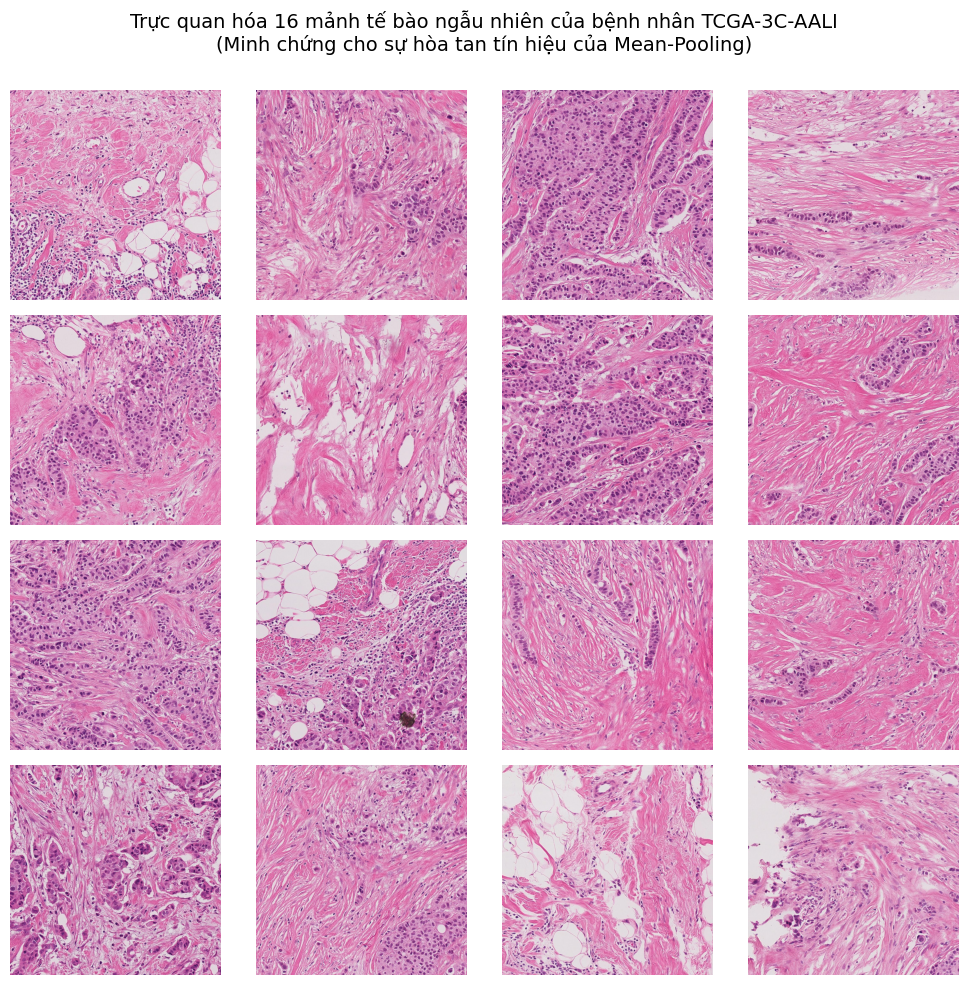

In [16]:
import random
from PIL import Image
import matplotlib.pyplot as plt

WSI_DIR = '/kaggle/input/datasets/jmalagontorres/tcga-brca-survival-analysis/WSIs' 

if len(X_data) > 0 and len(misclassified_idx) > 0:
    # Chọn ngẫu nhiên 1 bệnh nhân HER2 bị đoán sai
    target_idx = misclassified_idx[0]
    patient_id = valid_patients[target_idx] if 'valid_patients' in locals() else patient_ids[target_idx]
    true_lbl = "HER2"
    pred_lbl = ['LumA', 'LumB', 'Basal', 'HER2'][global_preds[target_idx]]
    
    print(f"Khám nghiệm Bệnh nhân: {patient_id}")
    print(f"Nhãn thực tế: {true_lbl} | Mô hình Naive đoán nhầm thành: {pred_lbl}")
    
    patient_folder = os.path.join(WSI_DIR, patient_id)
    if os.path.exists(patient_folder):
        all_patches = [f for f in os.listdir(patient_folder) if f.endswith('.jpg') or f.endswith('.png')]
        if len(all_patches) >= 16:
            sample_patches = random.sample(all_patches, 16)
            
            fig, axes = plt.subplots(4, 4, figsize=(10, 10))
            fig.suptitle(f"Trực quan hóa 16 mảnh tế bào ngẫu nhiên của bệnh nhân {patient_id}\n(Minh chứng cho sự hòa tan tín hiệu của Mean-Pooling)", fontsize=14)
            
            for i, ax in enumerate(axes.flat):
                img_path = os.path.join(patient_folder, sample_patches[i])
                img = Image.open(img_path)
                ax.imshow(img)
                ax.axis('off')
                
            plt.tight_layout()
            plt.subplots_adjust(top=0.9)
            plt.show()
        else:
            print(f"Bệnh nhân này có quá ít ảnh (<16) để hiển thị.")
    else:
        print(f"Không tìm thấy thư mục ảnh gốc tại {patient_folder}. Bỏ qua bước vẽ ảnh.")
elif len(X_data) > 0:
    print("Tuyệt vời, không có ca HER2 nào bị đoán sai (hoặc không có dữ liệu để vẽ)....")